# Kvasir-SEG: Polyp-PVT vs CFP + Polyp-PVT

This notebook compares the official Polyp-PVT architecture against the same model preceded by `mtlearn.layers.ConnectedFilterPreprocessingLayer` (CFP) under a leakage-controlled protocol.

Protocol locked in this notebook:

- public Kvasir-SEG only;
- one fixed split saved as JSON and reused across runs;
- `pvt_v2_b2.pth` is the only pretrained initialization;
- baseline Polyp-PVT and CFP + Polyp-PVT are both trained from that backbone initialization;
- model selection uses validation metrics only;
- the test set is evaluated only in the final comparison cell, after best-validation checkpoints are saved.

In `smoke` mode, the notebook uses `smoke_fraction` of each split. For example, `0.10` uses about 10% of train/val/test, and `0.20` uses about 20%. Set `run_mode = "full"` in the configuration cell to run the complete experiment. Device selection is `cuda -> mps -> cpu`; on MPS the notebook uses `384x384` by default because Polyp-PVT's SAM block calls `adaptive_avg_pool2d`, and PyTorch MPS currently fails for the original `352x352` feature size.

Sources:

- Kvasir-SEG: https://datasets.simula.no/kvasir-seg/
- Polyp-PVT: https://github.com/DengPingFan/Polyp-PVT
- PVTv2-B2 checkpoint mirror used by default: https://huggingface.co/Anonymity/pvt_pretrained/blob/main/pvt_v2_b2.pth

## Comentários do Desenho Experimental

Este notebook foi organizado para deixar claro onde cada decisão experimental entra no fluxo. As células de impressão resumem o protocolo e as auditorias contra vazamento; as células de plotagem ajudam a verificar visualmente o dataset, a inicialização quase-identidade da CFP, as curvas de treino e a comparação final.

As visualizações não participam do treino e não alteram checkpoints, splits ou métricas.

In [1]:
from __future__ import annotations

import csv
import hashlib
import json
import math
import os
import random
import shutil
import ssl
import subprocess
import sys
import time
import urllib.request
import zipfile
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'mtlearn' / 'python' / 'mtlearn').is_dir():
            return candidate
    raise RuntimeError('Could not locate mtlearn repository root.')


REPO_ROOT = find_repo_root()
# Prefer the repository Python package. Do not force build-jupyter bindings here: that
# build may be older than the Python layer and miss newer binding signatures.
python_src = REPO_ROOT / 'mtlearn' / 'python'
if str(python_src) not in sys.path:
    sys.path.insert(0, str(python_src))

print('repo:', REPO_ROOT)
print('python:', sys.executable)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('mps available:', bool(hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()))


repo: /Volumes/SSD/GitHub/mtlearn
python: /opt/anaconda3/bin/python
torch: 2.10.0
cuda available: False
mps available: True


## Configuration

Use `run_mode = "smoke"` for a reduced run that exercises the data, CFP cache, model, loss, metrics, and plots. In smoke mode, `smoke_fraction` controls the percentage of each split used: `0.10` means roughly 10%, `0.20` means roughly 20%.

Use `run_mode = "full"` for the real experiment on the complete fixed split.

In [2]:
@dataclass
class ExperimentConfig:
    seed: int = 42
    run_mode: str = 'smoke'  # 'smoke' or 'full'
    protocol_name: str = 'kvasir_seg_fixed_split_pvt_v2_b2_only'
    device_preference: str = 'auto'  # 'auto', 'cuda', 'mps', or 'cpu'
    image_size: int = 352
    batch_size: int = 4
    mps_image_size: int = 384
    mps_max_batch_size: int = 2
    num_workers: int = 0
    full_epochs: int = 100
    smoke_epochs: int = 1
    smoke_fraction: float = 0.10
    smoke_min_train_samples: int = 4
    smoke_min_val_samples: int = 2
    smoke_min_test_samples: int = 2
    val_fraction: float = 0.10
    test_fraction: float = 0.12
    lr_backbone: float = 1e-4
    lr_cfp: float = 1e-3
    weight_decay_backbone: float = 1e-4
    weight_decay_cfp: float = 1e-7
    grad_clip: float = 0.5
    cfp_identity_p0: float = 0.995
    cfp_score_sharpness: float = 1.0
    cfp_clamp: float = 12.0
    use_cfp_aux_loss: bool = True
    cfp_aux_lambda: float = 0.2
    cfp_aux_epochs: int = 50
    cfp_aux_warmup: int = 0
    cfp_aux_hold: int = 10
    cfp_aux_decay_to: float = 0.0
    allow_trained_polyp_pvt_checkpoints: bool = False


CFG = ExperimentConfig()


def select_device(preference: str = 'auto') -> torch.device:
    preference = preference.lower()
    if preference not in {'auto', 'cuda', 'mps', 'cpu'}:
        raise ValueError(f'Unsupported device preference: {preference}')
    if preference in {'auto', 'cuda'} and torch.cuda.is_available():
        return torch.device('cuda')
    if preference in {'auto', 'mps'} and hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    if preference == 'cuda':
        raise RuntimeError('CUDA was requested but is not available.')
    if preference == 'mps':
        raise RuntimeError('MPS was requested but is not available.')
    return torch.device('cpu')


DEVICE = select_device(CFG.device_preference)
if DEVICE.type == 'mps':
    # Polyp-PVT's SAM block uses AdaptiveAvgPool2d(output_size=6). With the
    # original 352 input, the relevant feature map is 44x44, and PyTorch MPS
    # does not implement non-divisible adaptive pooling. 384 -> 48x48 works.
    if CFG.image_size != CFG.mps_image_size:
        print(f'MPS selected: changing image_size from {CFG.image_size} to {CFG.mps_image_size}.')
        CFG.image_size = CFG.mps_image_size
    if CFG.batch_size > CFG.mps_max_batch_size:
        print(f'MPS selected: reducing batch_size from {CFG.batch_size} to {CFG.mps_max_batch_size}.')
        CFG.batch_size = CFG.mps_max_batch_size

DATA_ROOT = REPO_ROOT / 'dat' / 'kvasir_seg'
EXTERNAL_ROOT = REPO_ROOT / 'external_models'
POLYP_REPO = EXTERNAL_ROOT / 'Polyp-PVT'
PVT_PRETRAINED_PATH = POLYP_REPO / 'pretrained_pth' / 'pvt_v2_b2.pth'
OUT_DIR = REPO_ROOT / 'notebooks' / 'experiments' / 'out_kvasir_polyp_pvt_cfp'
SPLIT_PATH = OUT_DIR / f'splits_seed_{CFG.seed}.json'
SPLIT_AUDIT_PATH = OUT_DIR / f'split_audit_seed_{CFG.seed}.json'
PRETRAINING_REPORT_PATH = OUT_DIR / 'pretraining_report.json'
PROTOCOL_MANIFEST_PATH = OUT_DIR / f'protocol_manifest_seed_{CFG.seed}.json'

Kvasir_URL = 'https://datasets.simula.no/downloads/kvasir-seg.zip'
PVT_B2_URL = 'https://huggingface.co/Anonymity/pvt_pretrained/resolve/main/pvt_v2_b2.pth'
POLYP_PVT_GIT = 'https://github.com/DengPingFan/Polyp-PVT.git'

OUT_DIR.mkdir(parents=True, exist_ok=True)
EXTERNAL_ROOT.mkdir(parents=True, exist_ok=True)
print(asdict(CFG))
print('device:', DEVICE)
print('output:', OUT_DIR)

MPS selected: changing image_size from 352 to 384.
MPS selected: reducing batch_size from 4 to 2.
{'seed': 42, 'run_mode': 'smoke', 'protocol_name': 'kvasir_seg_fixed_split_pvt_v2_b2_only', 'device_preference': 'auto', 'image_size': 384, 'batch_size': 2, 'mps_image_size': 384, 'mps_max_batch_size': 2, 'num_workers': 0, 'full_epochs': 100, 'smoke_epochs': 1, 'smoke_fraction': 0.1, 'smoke_min_train_samples': 4, 'smoke_min_val_samples': 2, 'smoke_min_test_samples': 2, 'val_fraction': 0.1, 'test_fraction': 0.12, 'lr_backbone': 0.0001, 'lr_cfp': 0.001, 'weight_decay_backbone': 0.0001, 'weight_decay_cfp': 1e-07, 'grad_clip': 0.5, 'cfp_identity_p0': 0.995, 'cfp_score_sharpness': 1.0, 'cfp_clamp': 12.0, 'use_cfp_aux_loss': True, 'cfp_aux_lambda': 0.2, 'cfp_aux_epochs': 50, 'cfp_aux_warmup': 0, 'cfp_aux_hold': 10, 'cfp_aux_decay_to': 0.0, 'allow_trained_polyp_pvt_checkpoints': False}
device: mps
output: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp


In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(CFG.seed)


## Download and Prepare Resources

The Kvasir-SEG download is direct. The PVTv2-B2 checkpoint is mirrored on Hugging Face for reproducible scripted downloads; if that fails, place `pvt_v2_b2.pth` manually at `external_models/Polyp-PVT/pretrained_pth/pvt_v2_b2.pth`.

This notebook does not use the official trained Polyp-PVT segmentation checkpoint. It patches the official architecture code to load only `pvt_v2_b2.pth` and raises an error if another `.pth` file is found inside the cloned Polyp-PVT repository unless `allow_trained_polyp_pvt_checkpoints=True` is set explicitly.

In [4]:
def download_file(url: str, destination: Path, *, insecure_ssl: bool = False) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and destination.stat().st_size > 0:
        print(f'already exists: {destination} ({destination.stat().st_size / 1e6:.1f} MB)')
        return

    context = ssl._create_unverified_context() if insecure_ssl else None
    request = urllib.request.Request(url, headers={'User-Agent': 'mtlearn-kvasir-polyp-pvt-cfp/1.0'})
    tmp = destination.with_suffix(destination.suffix + '.part')
    with urllib.request.urlopen(request, context=context, timeout=120) as response, tmp.open('wb') as output:
        total = response.headers.get('Content-Length')
        total = int(total) if total else None
        done = 0
        last_report = -1
        while True:
            chunk = response.read(1024 * 1024)
            if not chunk:
                break
            output.write(chunk)
            done += len(chunk)
            if total:
                pct = int(100 * done / total)
                if pct // 10 != last_report // 10:
                    print(f'  {pct:3d}% ({done / 1e6:.1f} / {total / 1e6:.1f} MB)')
                    last_report = pct
    tmp.replace(destination)
    print(f'downloaded: {destination} ({destination.stat().st_size / 1e6:.1f} MB)')


def run(cmd: list[str], cwd: Path | None = None) -> None:
    print('+', ' '.join(map(str, cmd)))
    subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=True)


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open('rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def sha256_json(value: Any) -> str:
    payload = json.dumps(value, sort_keys=True, separators=(',', ':')).encode('utf-8')
    return hashlib.sha256(payload).hexdigest()

In [5]:
def prepare_kvasir_seg(data_root: Path = DATA_ROOT) -> tuple[Path, Path]:
    image_dir = data_root / 'images'
    mask_dir = data_root / 'masks'
    if image_dir.is_dir() and mask_dir.is_dir() and len(list(image_dir.iterdir())) >= 1000:
        print('Kvasir-SEG already prepared:', data_root)
        return image_dir, mask_dir

    archive = data_root.parent / 'kvasir-seg.zip'
    download_file(Kvasir_URL, archive, insecure_ssl=True)
    extract_dir = data_root.parent / '_kvasir_seg_extract'
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(extract_dir)

    candidates = []
    for candidate in [extract_dir, *extract_dir.rglob('*')]:
        if candidate.is_dir() and (candidate / 'images').is_dir() and (candidate / 'masks').is_dir():
            candidates.append(candidate)
    if not candidates:
        raise RuntimeError(f'Could not find images/masks directories under {extract_dir}')

    source = candidates[0]
    if data_root.exists():
        shutil.rmtree(data_root)
    data_root.mkdir(parents=True, exist_ok=True)
    shutil.move(str(source / 'images'), str(image_dir))
    shutil.move(str(source / 'masks'), str(mask_dir))
    if (source / 'kavsir_bboxes.json').exists():
        shutil.move(str(source / 'kavsir_bboxes.json'), str(data_root / 'kavsir_bboxes.json'))
    shutil.rmtree(extract_dir, ignore_errors=True)
    print('Kvasir-SEG prepared:', data_root)
    return image_dir, mask_dir


def prepare_polyp_pvt_repo(repo_dir: Path = POLYP_REPO) -> None:
    if not (repo_dir / 'lib' / 'pvt.py').is_file():
        repo_dir.parent.mkdir(parents=True, exist_ok=True)
        run(['git', 'clone', '--depth', '1', POLYP_PVT_GIT, str(repo_dir)])
    else:
        print('Polyp-PVT already available:', repo_dir)

    pvt_file = repo_dir / 'lib' / 'pvt.py'
    text = pvt_file.read_text()
    patched = text.replace("path = './pretrained_pth/pvt_v2_b2.pth'", f"path = r'{PVT_PRETRAINED_PATH}'")
    patched = patched.replace('save_model = torch.load(path)', "save_model = torch.load(path, map_location='cpu')")
    if patched != text:
        pvt_file.write_text(patched)
        print('patched Polyp-PVT pretrained path:', pvt_file)


def prepare_pvt_pretrained(path: Path = PVT_PRETRAINED_PATH) -> None:
    if path.exists() and path.stat().st_size > 0:
        print('PVTv2-B2 checkpoint already available:', path)
        return
    download_file(PVT_B2_URL, path)


def assert_pretraining_policy(repo_dir: Path = POLYP_REPO, path: Path = PVT_PRETRAINED_PATH) -> dict[str, Any]:
    if not path.is_file() or path.stat().st_size == 0:
        raise RuntimeError(f'Missing required PVTv2-B2 checkpoint: {path}')

    allowed = {path.resolve()}
    extra_pth = sorted(p for p in repo_dir.rglob('*.pth') if p.resolve() not in allowed)
    if extra_pth and not CFG.allow_trained_polyp_pvt_checkpoints:
        formatted = '\n'.join(f'  - {p}' for p in extra_pth)
        raise RuntimeError(
            'Potential leakage risk: found additional .pth files inside the Polyp-PVT repo. '
            'This protocol allows only pvt_v2_b2.pth as pretrained initialization.\n' + formatted
        )

    pvt_source = (repo_dir / 'lib' / 'pvt.py').read_text()
    if str(path) not in pvt_source:
        raise RuntimeError('Polyp-PVT source is not patched to load the configured pvt_v2_b2.pth path.')
    if "torch.load(path, map_location='cpu')" not in pvt_source:
        raise RuntimeError('Polyp-PVT source is not patched for CPU-safe checkpoint loading.')

    report = {
        'policy': 'pvt_v2_b2_only_no_official_trained_polyp_pvt_checkpoint',
        'checkpoint_path': str(path),
        'checkpoint_sha256': sha256_file(path),
        'extra_pth_files': [str(p) for p in extra_pth],
        'allow_trained_polyp_pvt_checkpoints': CFG.allow_trained_polyp_pvt_checkpoints,
    }
    with PRETRAINING_REPORT_PATH.open('w') as f:
        json.dump(report, f, indent=2)
    print('pretraining policy ok:', report)
    return report


image_dir, mask_dir = prepare_kvasir_seg()
prepare_polyp_pvt_repo()
prepare_pvt_pretrained()
PRETRAINING_REPORT = assert_pretraining_policy()

Kvasir-SEG already prepared: /Volumes/SSD/GitHub/mtlearn/dat/kvasir_seg
+ git clone --depth 1 https://github.com/DengPingFan/Polyp-PVT.git /Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT


Cloning into '/Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT'...


patched Polyp-PVT pretrained path: /Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT/lib/pvt.py


    1% (1.0 / 101.5 MB)


   10% (10.5 / 101.5 MB)


...

   60% (61.9 / 101.5 MB)


   70% (71.3 / 101.5 MB)


   80% (81.8 / 101.5 MB)


   90% (92.3 / 101.5 MB)


  100% (101.5 / 101.5 MB)
downloaded: /Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT/pretrained_pth/pvt_v2_b2.pth (101.5 MB)
pretraining policy ok: {'policy': 'pvt_v2_b2_only_no_official_trained_polyp_pvt_checkpoint', 'checkpoint_path': '/Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT/pretrained_pth/pvt_v2_b2.pth', 'checkpoint_sha256': '80711cd1b37ffba12bec6c7a2a7c54efe2315ed635e6d2055fd51c3e909ede4d', 'extra_pth_files': [], 'allow_trained_polyp_pvt_checkpoints': False}


## Splits and Datasets

The first run creates a deterministic split and saves it as a canonical JSON file containing image names. Later runs reuse the same split and hydrate paths from the local Kvasir-SEG directory.

The audit cell hashes images and masks, then asserts that there is no train/validation/test overlap by name, image hash, or full image-mask pair hash.

In `smoke` mode, the dataset objects are deterministic subsets of the fixed split. The subset size is controlled by `CFG.smoke_fraction`, applied independently to train, validation, and test. The dataset returns raw RGB tensors in `[0, 1]`; ImageNet normalization is applied inside each model wrapper so CFP operates on image intensities rather than ImageNet-normalized values.

In [6]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
SPLIT_PARTS = ('train', 'val', 'test')


def pair_kvasir_files(image_dir: Path, mask_dir: Path) -> list[dict[str, str]]:
    images = {p.stem: p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    masks = {p.stem: p for p in mask_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    keys = sorted(set(images) & set(masks))
    if not keys:
        raise RuntimeError('No image/mask pairs found.')
    missing_masks = sorted(set(images) - set(masks))[:5]
    missing_images = sorted(set(masks) - set(images))[:5]
    if missing_masks or missing_images:
        print('warning: unmatched files:', {'missing_masks': missing_masks, 'missing_images': missing_images})
    return [{'name': k, 'image': str(images[k]), 'mask': str(masks[k])} for k in keys]


def split_payload_to_names(payload: dict[str, Any]) -> dict[str, list[str]]:
    raw_splits = payload.get('splits', payload)
    names: dict[str, list[str]] = {}
    for part in SPLIT_PARTS:
        if part not in raw_splits:
            raise RuntimeError(f'Missing split part {part!r} in {SPLIT_PATH}')
        values = raw_splits[part]
        names[part] = [item['name'] if isinstance(item, dict) else str(item) for item in values]
    return names


def save_split_names(split_names: dict[str, list[str]], split_path: Path = SPLIT_PATH) -> None:
    payload = {
        'protocol': CFG.protocol_name,
        'dataset': 'Kvasir-SEG',
        'seed': CFG.seed,
        'split_policy': 'fixed_random_split_saved_by_image_name',
        'val_fraction': CFG.val_fraction,
        'test_fraction': CFG.test_fraction,
        'counts': {part: len(split_names[part]) for part in SPLIT_PARTS},
        'split_hash': sha256_json(split_names),
        'splits': split_names,
    }
    split_path.parent.mkdir(parents=True, exist_ok=True)
    with split_path.open('w') as f:
        json.dump(payload, f, indent=2)


def hydrate_split(split_names: dict[str, list[str]], pairs: list[dict[str, str]]) -> dict[str, list[dict[str, str]]]:
    pair_by_name = {item['name']: item for item in pairs}
    expected = set(pair_by_name)
    observed = {name for values in split_names.values() for name in values}
    missing = sorted(expected - observed)
    extra = sorted(observed - expected)
    if missing or extra:
        raise RuntimeError(
            'Split JSON does not match the local Kvasir-SEG files: '
            f'{len(missing)} missing names, {len(extra)} unknown names.'
        )
    return {part: [pair_by_name[name] for name in split_names[part]] for part in SPLIT_PARTS}


def create_or_load_split(pairs: list[dict[str, str]], split_path: Path = SPLIT_PATH) -> dict[str, list[dict[str, str]]]:
    if split_path.exists():
        with split_path.open() as f:
            split_names = split_payload_to_names(json.load(f))
        print('loaded split:', split_path)
    else:
        rng = random.Random(CFG.seed)
        shuffled = [item['name'] for item in pairs]
        rng.shuffle(shuffled)
        n = len(shuffled)
        n_test = max(1, round(n * CFG.test_fraction))
        remaining = n - n_test
        n_val = max(1, round(remaining * CFG.val_fraction))
        split_names = {
            'train': shuffled[: remaining - n_val],
            'val': shuffled[remaining - n_val: remaining],
            'test': shuffled[remaining:],
        }
        print('created split:', split_path)

    split = hydrate_split(split_names, pairs)
    save_split_names(split_names, split_path)
    print('saved canonical split:', split_path)
    return split


def duplicate_values(values: list[str]) -> list[str]:
    seen: set[str] = set()
    dupes: set[str] = set()
    for value in values:
        if value in seen:
            dupes.add(value)
        seen.add(value)
    return sorted(dupes)


def cross_split_overlaps(records_by_part: dict[str, list[dict[str, str]]], key: str) -> dict[str, list[str]]:
    overlaps: dict[str, list[str]] = {}
    for i, left in enumerate(SPLIT_PARTS):
        left_values = {record[key] for record in records_by_part[left]}
        for right in SPLIT_PARTS[i + 1:]:
            common = sorted(left_values & {record[key] for record in records_by_part[right]})
            if common:
                overlaps[f'{left}/{right}'] = common[:20]
    return overlaps


def audit_split(split: dict[str, list[dict[str, str]]], pairs: list[dict[str, str]]) -> dict[str, Any]:
    records_by_part: dict[str, list[dict[str, str]]] = {}
    for part in SPLIT_PARTS:
        records = []
        for item in split[part]:
            image_sha = sha256_file(Path(item['image']))
            mask_sha = sha256_file(Path(item['mask']))
            records.append({
                'name': item['name'],
                'image': item['image'],
                'mask': item['mask'],
                'image_sha256': image_sha,
                'mask_sha256': mask_sha,
                'pair_sha256': sha256_json({'image': image_sha, 'mask': mask_sha}),
            })
        records_by_part[part] = records

    within_duplicates = {
        part: {
            'name': duplicate_values([record['name'] for record in records]),
            'image_sha256': duplicate_values([record['image_sha256'] for record in records]),
            'pair_sha256': duplicate_values([record['pair_sha256'] for record in records]),
        }
        for part, records in records_by_part.items()
    }
    cross_overlaps = {
        'name': cross_split_overlaps(records_by_part, 'name'),
        'image_sha256': cross_split_overlaps(records_by_part, 'image_sha256'),
        'pair_sha256': cross_split_overlaps(records_by_part, 'pair_sha256'),
        'mask_sha256_warning_only': cross_split_overlaps(records_by_part, 'mask_sha256'),
    }
    split_names = {part: [record['name'] for record in records_by_part[part]] for part in SPLIT_PARTS}
    audit = {
        'protocol': CFG.protocol_name,
        'dataset': 'Kvasir-SEG',
        'dataset_pair_count': len(pairs),
        'split_path': str(SPLIT_PATH),
        'split_hash': sha256_json(split_names),
        'counts': {part: len(records_by_part[part]) for part in SPLIT_PARTS},
        'within_duplicates': within_duplicates,
        'cross_split_overlaps': cross_overlaps,
        'records': records_by_part,
    }

    blocking_issues = []
    for part, checks in within_duplicates.items():
        for key, values in checks.items():
            if values:
                blocking_issues.append(f'duplicate {key} inside {part}: {values[:5]}')
    for key in ('name', 'image_sha256', 'pair_sha256'):
        if cross_overlaps[key]:
            blocking_issues.append(f'cross-split overlap by {key}: {cross_overlaps[key]}')
    if blocking_issues:
        raise RuntimeError('Potential split leakage detected:\n' + '\n'.join(blocking_issues))

    with SPLIT_AUDIT_PATH.open('w') as f:
        json.dump(audit, f, indent=2)
    print('split audit ok:', {'counts': audit['counts'], 'split_hash': audit['split_hash']})
    return audit


def save_protocol_manifest(split_audit: dict[str, Any], pretraining_report: dict[str, Any]) -> dict[str, Any]:
    manifest = {
        'protocol_name': CFG.protocol_name,
        'dataset': {
            'name': 'Kvasir-SEG',
            'source_url': 'https://datasets.simula.no/kvasir-seg/',
            'pair_count': split_audit['dataset_pair_count'],
        },
        'split': {
            'path': str(SPLIT_PATH),
            'audit_path': str(SPLIT_AUDIT_PATH),
            'hash': split_audit['split_hash'],
            'counts': split_audit['counts'],
            'leakage_audit': 'no name/image/pair-hash overlap across train/val/test',
        },
        'initialization': {
            'policy': 'only pvt_v2_b2.pth; no official trained Polyp-PVT checkpoint',
            'checkpoint_path': pretraining_report['checkpoint_path'],
            'checkpoint_sha256': pretraining_report['checkpoint_sha256'],
        },
        'models': {
            'baseline': 'Polyp-PVT initialized from pvt_v2_b2.pth',
            'cfp': 'identity-initialized CFP followed by Polyp-PVT initialized from pvt_v2_b2.pth',
        },
        'selection_and_test': {
            'checkpoint_selection': 'best validation soft_dice',
            'training_uses_test_set': False,
            'test_policy': 'test set is evaluated only in the final comparison cell after validation-selected checkpoints are saved',
        },
        'config': asdict(CFG),
    }
    with PROTOCOL_MANIFEST_PATH.open('w') as f:
        json.dump(manifest, f, indent=2)
    print('protocol manifest:', PROTOCOL_MANIFEST_PATH)
    return manifest


pairs = pair_kvasir_files(image_dir, mask_dir)
split = create_or_load_split(pairs)
SPLIT_AUDIT = audit_split(split, pairs)
PROTOCOL_MANIFEST = save_protocol_manifest(SPLIT_AUDIT, PRETRAINING_REPORT)
print({k: len(v) for k, v in split.items()})

created split: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp/splits_seed_42.json
saved canonical split: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp/splits_seed_42.json


split audit ok: {'counts': {'train': 792, 'val': 88, 'test': 120}, 'split_hash': '97f36908685480c4eba6a9e16bb569e0061c1072ee660f2c390732e2fc5f8f4e'}
protocol manifest: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp/protocol_manifest_seed_42.json
{'train': 792, 'val': 88, 'test': 120}


## Impressões do Protocolo e Auditoria

Esta célula imprime os pontos que precisam aparecer no relatório experimental: fonte do dataset, tamanhos de split, política de pré-treinamento, hash do split e resultado da auditoria contra vazamento.

In [7]:
def print_protocol_summary() -> None:
    print('=== Protocolo ===')
    print(f'nome: {CFG.protocol_name}')
    print(f'run_mode: {CFG.run_mode}')
    print(f'device: {DEVICE}')
    print(f'image_size: {CFG.image_size}')
    print(f'batch_size: {CFG.batch_size}')
    if CFG.run_mode == 'smoke':
        min_by_split = {
            'train': CFG.smoke_min_train_samples,
            'val': CFG.smoke_min_val_samples,
            'test': CFG.smoke_min_test_samples,
        }
        effective_counts = {}
        for part in SPLIT_PARTS:
            split_size = SPLIT_AUDIT['counts'][part]
            by_fraction = max(1, int(round(split_size * CFG.smoke_fraction)))
            effective_counts[part] = min(split_size, max(min_by_split[part], by_fraction))
        print(f'smoke_fraction: {CFG.smoke_fraction:.1%}')
        print(
            'effective train/val/test: '
            f'{effective_counts["train"]}/{effective_counts["val"]}/{effective_counts["test"]}'
        )
    print()

    print('=== Dataset e split fixo ===')
    print(f'dataset: Kvasir-SEG publico')
    print(f'total de pares imagem/mascara: {SPLIT_AUDIT["dataset_pair_count"]}')
    for part in SPLIT_PARTS:
        print(f'{part:>5}: {SPLIT_AUDIT["counts"][part]} imagens')
    print(f'split JSON: {SPLIT_PATH}')
    print(f'split hash: {SPLIT_AUDIT["split_hash"]}')
    print()

    print('=== Auditoria contra vazamento ===')
    checked = ('name', 'image_sha256', 'pair_sha256')
    for key in checked:
        overlaps = SPLIT_AUDIT['cross_split_overlaps'][key]
        print(f'overlap por {key}: {len(overlaps)} pares de splits com intersecao')
    print('bloqueante: qualquer overlap por nome, hash de imagem ou hash do par falha o notebook')
    print()

    print('=== Inicializacao permitida ===')
    print(PRETRAINING_REPORT['policy'])
    print(f'checkpoint: {PRETRAINING_REPORT["checkpoint_path"]}')
    print(f'checkpoint sha256: {PRETRAINING_REPORT["checkpoint_sha256"]}')
    print(f'checkpoints .pth extras no Polyp-PVT: {len(PRETRAINING_REPORT["extra_pth_files"])}')
    print()

    print('=== Seleção e teste ===')
    print(PROTOCOL_MANIFEST['selection_and_test']['checkpoint_selection'])
    print(PROTOCOL_MANIFEST['selection_and_test']['test_policy'])


print_protocol_summary()

=== Protocolo ===
nome: kvasir_seg_fixed_split_pvt_v2_b2_only
run_mode: smoke
device: mps
image_size: 384
batch_size: 2
smoke_fraction: 10.0%
effective train/val/test: 79/9/12

=== Dataset e split fixo ===
dataset: Kvasir-SEG publico
total de pares imagem/mascara: 1000
train: 792 imagens
  val: 88 imagens
 test: 120 imagens
split JSON: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp/splits_seed_42.json
split hash: 97f36908685480c4eba6a9e16bb569e0061c1072ee660f2c390732e2fc5f8f4e

=== Auditoria contra vazamento ===
overlap por name: 0 pares de splits com intersecao
overlap por image_sha256: 0 pares de splits com intersecao
overlap por pair_sha256: 0 pares de splits com intersecao
bloqueante: qualquer overlap por nome, hash de imagem ou hash do par falha o notebook

=== Inicializacao permitida ===
pvt_v2_b2_only_no_official_trained_polyp_pvt_checkpoint
checkpoint: /Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT/pretrained_pth/pvt_v2_b2.pth
checkpoint sha25

In [8]:
class KvasirSegDataset(Dataset):
    def __init__(self, items: list[dict[str, str]], image_size: int = 352):
        self.items = items
        self.image_size = int(image_size)

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int):
        item = self.items[idx]
        image = Image.open(item['image']).convert('RGB')
        mask = Image.open(item['mask']).convert('L')
        image = TF.resize(image, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.image_size, self.image_size], interpolation=InterpolationMode.NEAREST)
        x = TF.to_tensor(image).float()
        y = (TF.to_tensor(mask).float() > 0.5).float()
        return x, y, item['name']


class IndexedDataset(Dataset):
    def __init__(self, base: Dataset):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx: int):
        sample = self.base[idx]
        return (sample[0], idx), sample[1]


def maybe_subset(dataset: Dataset, limit: int | None) -> Dataset:
    if limit is None or limit >= len(dataset):
        return dataset
    return Subset(dataset, list(range(limit)))


def smoke_sample_count(split_name: str, split_size: int) -> int:
    if not (0.0 < CFG.smoke_fraction <= 1.0):
        raise ValueError(f'smoke_fraction must be in (0, 1], got {CFG.smoke_fraction}')
    min_by_split = {
        'train': CFG.smoke_min_train_samples,
        'val': CFG.smoke_min_val_samples,
        'test': CFG.smoke_min_test_samples,
    }
    if split_name not in min_by_split:
        raise ValueError(f'Unknown split name: {split_name}')
    by_fraction = max(1, int(round(split_size * CFG.smoke_fraction)))
    return min(split_size, max(min_by_split[split_name], by_fraction))


def maybe_smoke_subset(dataset: Dataset, split_name: str) -> Dataset:
    if CFG.run_mode != 'smoke':
        return dataset
    limit = smoke_sample_count(split_name, len(dataset))
    print(f'smoke subset {split_name}: {limit}/{len(dataset)} samples ({CFG.smoke_fraction:.1%})')
    return maybe_subset(dataset, limit)


def make_loader(dataset: Dataset, *, shuffle: bool, indexed: bool = False, seed_offset: int = 0) -> DataLoader:
    wrapped = IndexedDataset(dataset) if indexed else dataset
    generator = torch.Generator()
    generator.manual_seed(CFG.seed + seed_offset)
    return DataLoader(
        wrapped,
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
        generator=generator,
    )


train_dataset = KvasirSegDataset(split['train'], CFG.image_size)
val_dataset = KvasirSegDataset(split['val'], CFG.image_size)
test_dataset = KvasirSegDataset(split['test'], CFG.image_size)

train_dataset = maybe_smoke_subset(train_dataset, 'train')
val_dataset = maybe_smoke_subset(val_dataset, 'val')
test_dataset = maybe_smoke_subset(test_dataset, 'test')

train_loader_base = make_loader(train_dataset, shuffle=True, indexed=False, seed_offset=1)
train_loader_cfp_prepass = make_loader(train_dataset, shuffle=False, indexed=False, seed_offset=2)
train_loader_cfp = make_loader(train_dataset, shuffle=True, indexed=True, seed_offset=1)
val_loader = make_loader(val_dataset, shuffle=False, indexed=False, seed_offset=3)
test_loader = make_loader(test_dataset, shuffle=False, indexed=False, seed_offset=4)
print('effective sizes:', len(train_dataset), len(val_dataset), len(test_dataset))


smoke subset train: 79/792 samples (10.0%)
smoke subset val: 9/88 samples (10.0%)
smoke subset test: 12/120 samples (10.0%)
effective sizes: 79 9 12


## Plotagens do Dataset

Estas figuras ajudam a detectar problemas simples antes de treinar: contagem por split, tamanho efetivo usado no modo `smoke`, fração de pixels positivos nas máscaras e amostras RGB/máscara/overlay.

saved: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp/dataset_diagnostics.png


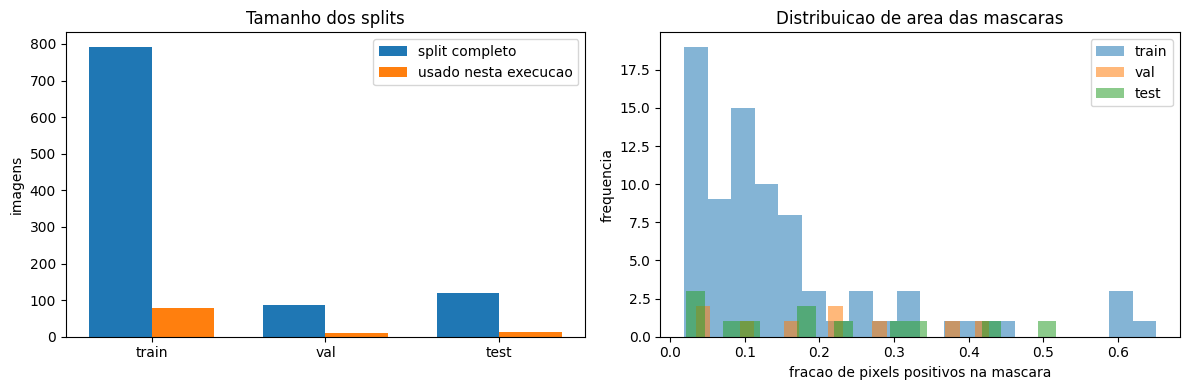

saved: /Volumes/SSD/GitHub/mtlearn/notebooks/experiments/out_kvasir_polyp_pvt_cfp/train_samples.png


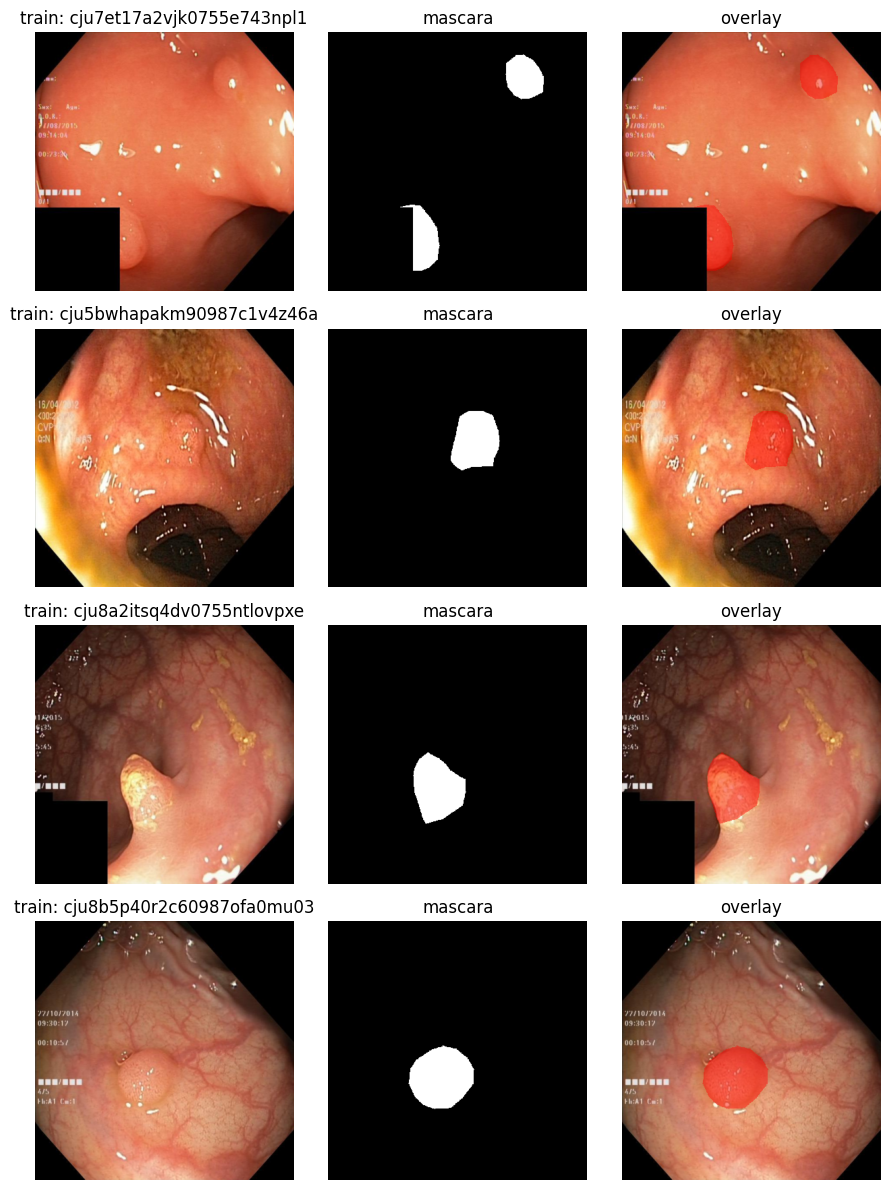

In [9]:
def _dataset_mask_fractions(dataset: Dataset, max_items: int = 120) -> list[float]:
    values = []
    limit = min(len(dataset), max_items)
    for idx in range(limit):
        _, mask, _ = dataset[idx]
        values.append(float(mask.mean().item()))
    return values


def plot_dataset_diagnostics() -> None:
    full_counts = {part: len(split[part]) for part in SPLIT_PARTS}
    effective_counts = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
    labels = list(SPLIT_PARTS)
    x = np.arange(len(labels))
    width = 0.36

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(x - width / 2, [full_counts[k] for k in labels], width, label='split completo')
    axes[0].bar(x + width / 2, [effective_counts[k] for k in labels], width, label='usado nesta execucao')
    axes[0].set_xticks(x, labels)
    axes[0].set_ylabel('imagens')
    axes[0].set_title('Tamanho dos splits')
    axes[0].legend()

    for label, dataset in [('train', train_dataset), ('val', val_dataset), ('test', test_dataset)]:
        fractions = _dataset_mask_fractions(dataset)
        if fractions:
            axes[1].hist(fractions, bins=20, alpha=0.55, label=label)
    axes[1].set_xlabel('fracao de pixels positivos na mascara')
    axes[1].set_ylabel('frequencia')
    axes[1].set_title('Distribuicao de area das mascaras')
    axes[1].legend()
    fig.tight_layout()
    path = OUT_DIR / 'dataset_diagnostics.png'
    fig.savefig(path, dpi=160)
    print('saved:', path)
    plt.show()


def plot_dataset_samples(dataset: Dataset, split_name: str, max_items: int = 4) -> None:
    n = min(len(dataset), max_items)
    if n == 0:
        print(f'No samples to plot for {split_name}.')
        return
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for row in range(n):
        image, mask, name = dataset[row]
        image_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()
        overlay = image_np.copy()
        overlay[mask_np > 0.5] = 0.55 * overlay[mask_np > 0.5] + np.array([0.45, 0.0, 0.0])

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title(f'{split_name}: {name}')
        axes[row, 1].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title('mascara')
        axes[row, 2].imshow(np.clip(overlay, 0, 1))
        axes[row, 2].set_title('overlay')
        for col in range(3):
            axes[row, col].axis('off')
    fig.tight_layout()
    path = OUT_DIR / f'{split_name}_samples.png'
    fig.savefig(path, dpi=160)
    print('saved:', path)
    plt.show()


plot_dataset_diagnostics()
plot_dataset_samples(train_dataset, 'train')

## Model Wrappers

Comentário de implementação: os dois modelos recebem a mesma imagem RGB bruta em `[0, 1]`. A diferença controlada é apenas a presença da CFP antes do backbone.

- Baseline: `RGB -> ImageNetNormalize -> Polyp-PVT`.
- CFP: `RGB -> CFP(identity init + cache) -> clamp [0, 1] -> ImageNetNormalize -> Polyp-PVT`.

A cabeça auxiliar de 1x1 é usada apenas no caminho CFP para enviar gradiente diretamente para a saída da CFP; as métricas finais continuam vindo das saídas principais do Polyp-PVT.

In [10]:
if str(POLYP_REPO) not in sys.path:
    sys.path.insert(0, str(POLYP_REPO))
from lib.pvt import PolypPVT

from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer


def install_compute_attributes_dtype_compat() -> None:
    """Handle native mtlearn builds that do not yet expose the dtype argument."""
    try:
        probe = np.zeros((2, 2), dtype=np.uint8)
        tree = morphology.create_max_tree(probe)
        morphology.compute_attributes(tree, [morphology.AttributeType.AREA], dtype=None)
        return
    except TypeError:
        pass

    def compute_attributes_compat(tree, attributes, output_space=morphology.NodeIdSpace.MORPHOLOGICAL_TREE, dtype=None):
        return morphology._backend.Attribute.computeAttributes(tree, attributes, output_space)

    morphology.compute_attributes = compute_attributes_compat
    print('Installed mtlearn compute_attributes compatibility shim for native bindings without dtype support.')


install_compute_attributes_dtype_compat()


class ImageNetNormalize(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean.to(dtype=x.dtype, device=x.device)) / self.std.to(dtype=x.dtype, device=x.device)


# Fluxo baseline: RGB bruto -> normalizacao ImageNet -> Polyp-PVT.
class BaselinePolypPVT(nn.Module):
    def __init__(self):
        super().__init__()
        self.normalize = ImageNetNormalize()
        self.polyp_pvt = PolypPVT()

    def forward(self, x_raw: torch.Tensor):
        x_raw = x_raw.to(DEVICE, non_blocking=True)
        return self.polyp_pvt(self.normalize(x_raw))


# Fluxo CFP: RGB bruto -> CFP -> intervalo [0, 1] -> normalizacao ImageNet -> Polyp-PVT.
class CFPPolypPVT(nn.Module):
    def __init__(self, cfp_layer: ConnectedFilterPreprocessingLayer):
        super().__init__()
        self.cfp = cfp_layer
        self.normalize = ImageNetNormalize()
        self.polyp_pvt = PolypPVT()
        self.uses_cfp_aux_loss = True
        self.aux_head = nn.Conv2d(3, 1, kernel_size=1)
        self.last_aux_logits = None
        with torch.no_grad():
            self.aux_head.weight.zero_()
            self.aux_head.weight[0, :, 0, 0] = torch.tensor([0.299, 0.587, 0.114])
            self.aux_head.bias.fill_(-0.5)

    def forward(self, x_raw_or_cached):
        x_cfp = self.cfp(x_raw_or_cached)
        x_unit = torch.clamp(x_cfp / 255.0, 0.0, 1.0)
        self.last_aux_logits = self.aux_head(x_unit)
        return self.polyp_pvt(self.normalize(x_unit))


def cfp_shape_attributes():
    shape_group = getattr(morphology.AttributeGroup, 'SHAPE', None)
    if shape_group is not None:
        return (shape_group,)
    return (
        morphology.AttributeType.AREA,
        morphology.AttributeType.COMPACTNESS,
        morphology.AttributeType.CIRCULARITY,
        morphology.AttributeType.RECTANGULARITY,
        morphology.AttributeType.GRAY_HEIGHT,
    )


def build_cfp_layer() -> ConnectedFilterPreprocessingLayer:
    layer = ConnectedFilterPreprocessingLayer(
        in_channels=3,
        filter_specs=[
            {
                'name': 'tos_shape',
                'tree_type': morphology.TreeType.TREE_OF_SHAPES,
                'attributes': cfp_shape_attributes(),
                'tos_interpolation': 'self-dual',
            }
        ],
        device=DEVICE,
        scale_mode='dataset_clipped_zscore01',
        score_sharpness=CFG.cfp_score_sharpness,
        clamp=CFG.cfp_clamp,
    )
    # Inicializacao quase-identidade: a CFP comeca preservando a imagem.
    layer.init_identity(p0=CFG.cfp_identity_p0)
    assert layer.out_channels == 3, f'CFP must preserve RGB channels; got {layer.out_channels}'
    return layer


/opt/anaconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT/lib/pvtv2.py:387: UserWarning: Overwriting pvt_v2_b0 in registry with lib.pvtv2.pvt_v2_b0. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/Volumes/SSD/GitHub/mtlearn/external_models/Polyp-PVT/lib/pvtv2.py:397: UserWarning: Overwriting pvt_v2_b1 in registry with lib.pvtv2.pvt_v2_b1. This is because the name be

## CFP Cache Prepass

Comentário de protocolo: o cache da CFP é construído somente no conjunto de treino. As estatísticas de normalização da CFP são congeladas depois desse prepass; validação e teste usam essas estatísticas de treino, sem recalibrar em dados fora do treino.

In [ ]:
cfp_layer = build_cfp_layer()
print('Building CFP cache and training statistics...')
_ = cfp_layer.build_dataloader_cached(train_loader_cfp_prepass)
cfp_layer.save_stats(str(OUT_DIR / 'cfp_train_stats.pt'))
print('CFP stats frozen:', cfp_layer._stats_frozen)
print('cached training samples:', cfp_layer.cached_sample_count())


In [ ]:
@torch.no_grad()
def cfp_identity_report(cfp_layer: ConnectedFilterPreprocessingLayer, loader: DataLoader, max_batches: int = 1) -> dict[str, float]:
    diffs = []
    for batch_i, batch in enumerate(loader):
        if batch_i >= max_batches:
            break
        images = batch[0]
        y = torch.clamp(cfp_layer(images) / 255.0, 0.0, 1.0).cpu()
        diffs.append((y - images).abs().mean().item())
    return {'mean_abs_identity_error': float(np.mean(diffs)) if diffs else float('nan')}


identity_report = cfp_identity_report(cfp_layer, train_loader_base)
print(identity_report)
with (OUT_DIR / 'cfp_identity_report.json').open('w') as f:
    json.dump(identity_report, f, indent=2)


## Plotagem da Inicialização CFP

Esta célula verifica visualmente a hipótese de inicialização: no início, a CFP deve alterar pouco a imagem RGB. A terceira coluna mostra o erro absoluto médio por pixel, ampliado apenas para inspeção visual.

In [ ]:
@torch.no_grad()
def plot_cfp_identity_preview(cfp_layer: ConnectedFilterPreprocessingLayer, loader: DataLoader, max_items: int = 3) -> None:
    batch = next(iter(loader), None)
    if batch is None:
        print('No batch available for CFP identity preview.')
        return
    images = batch[0]
    cfp_images = torch.clamp(cfp_layer(images) / 255.0, 0.0, 1.0).cpu()
    images = images.cpu()
    n = min(images.shape[0], max_items)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for row in range(n):
        original = images[row].permute(1, 2, 0).numpy()
        filtered = cfp_images[row].permute(1, 2, 0).numpy()
        diff = np.abs(filtered - original).mean(axis=2)
        axes[row, 0].imshow(original)
        axes[row, 0].set_title('RGB original')
        axes[row, 1].imshow(filtered)
        axes[row, 1].set_title('CFP inicial')
        axes[row, 2].imshow(diff, cmap='magma')
        axes[row, 2].set_title('|CFP - RGB|')
        for col in range(3):
            axes[row, col].axis('off')
    fig.tight_layout()
    path = OUT_DIR / 'cfp_identity_preview.png'
    fig.savefig(path, dpi=160)
    print('saved:', path)
    plt.show()


plot_cfp_identity_preview(cfp_layer, train_loader_base)

## Loss, Metrics, Training, and Evaluation

Comentário de protocolo: a loss principal segue a estrutura do Polyp-PVT, com BCE ponderada por borda + IoU ponderada. Para `CFP + Polyp-PVT`, a loss auxiliar atua diretamente sobre uma cabeça 1x1 ligada à saída da CFP, seguindo a ideia de aumentar o gradiente disponível para a etapa de pré-processamento.

As métricas são calculadas de `sigmoid(P1 + P2)` sem normalização min/max por imagem, preservando calibração probabilística.

In [ ]:
def structure_loss(pred: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    weit = 1 + 5 * torch.abs(F.avg_pool2d(mask, kernel_size=31, stride=1, padding=15) - mask)
    wbce = F.binary_cross_entropy_with_logits(pred, mask, reduction='none')
    wbce = (weit * wbce).sum(dim=(2, 3)) / weit.sum(dim=(2, 3)).clamp_min(1e-8)

    pred_prob = torch.sigmoid(pred)
    inter = ((pred_prob * mask) * weit).sum(dim=(2, 3))
    union = ((pred_prob + mask) * weit).sum(dim=(2, 3))
    wiou = 1 - (inter + 1) / (union - inter + 1)
    return (wbce + wiou).mean()


def unpack_batch(batch):
    if isinstance(batch, (tuple, list)) and len(batch) == 2 and isinstance(batch[0], (tuple, list)):
        model_input = batch[0]
        mask = batch[1]
        names = None
    else:
        model_input = batch[0]
        mask = batch[1]
        names = batch[2] if len(batch) > 2 else None
    return model_input, mask.to(DEVICE, non_blocking=True), names


def combined_logits(outputs, target_shape: tuple[int, int]) -> torch.Tensor:
    p1, p2 = outputs
    logits = p1 + p2
    if logits.shape[-2:] != target_shape:
        logits = F.interpolate(logits, size=target_shape, mode='bilinear', align_corners=False)
    return logits


def batch_metrics(logits: torch.Tensor, mask: torch.Tensor, threshold: float = 0.5) -> dict[str, float]:
    prob = torch.sigmoid(logits)
    pred = (prob >= threshold).float()
    dims = (1, 2, 3)
    eps = 1e-7
    soft_inter = (prob * mask).sum(dim=dims)
    soft_union = prob.sum(dim=dims) + mask.sum(dim=dims)
    soft_dice = (2 * soft_inter + eps) / (soft_union + eps)
    soft_iou = (soft_inter + eps) / (prob.sum(dim=dims) + mask.sum(dim=dims) - soft_inter + eps)

    inter = (pred * mask).sum(dim=dims)
    pred_sum = pred.sum(dim=dims)
    mask_sum = mask.sum(dim=dims)
    dice = (2 * inter + eps) / (pred_sum + mask_sum + eps)
    iou = (inter + eps) / (pred_sum + mask_sum - inter + eps)
    precision = (inter + eps) / (pred_sum + eps)
    recall = (inter + eps) / (mask_sum + eps)
    mae = torch.abs(prob - mask).mean(dim=dims)
    return {
        'soft_dice': soft_dice.mean().item(),
        'soft_iou': soft_iou.mean().item(),
        'dice': dice.mean().item(),
        'iou': iou.mean().item(),
        'precision': precision.mean().item(),
        'recall': recall.mean().item(),
        'mae': mae.mean().item(),
    }


def average_dicts(rows: list[dict[str, float]]) -> dict[str, float]:
    if not rows:
        return {}
    return {key: float(np.mean([row[key] for row in rows])) for key in rows[0]}


class LambdaAuxScheduler:
    def __init__(self, total_epochs: int, max_val: float, warmup: int = 0, hold: int = 10, decay_to: float = 0.0):
        self.total_epochs = max(0, int(total_epochs))
        self.max_val = float(max_val)
        self.warmup = max(0, int(warmup))
        self.hold = max(0, int(hold))
        self.decay_to = float(decay_to)

    def __call__(self, epoch: int) -> float:
        if self.total_epochs <= 0 or epoch > self.total_epochs:
            return 0.0
        if self.warmup > 0 and epoch <= self.warmup:
            return self.max_val * epoch / self.warmup
        hold_end = self.warmup + self.hold
        if epoch <= hold_end:
            return self.max_val
        remaining = max(1, self.total_epochs - hold_end)
        progress = min(1.0, max(0.0, (epoch - hold_end) / remaining))
        return self.max_val + progress * (self.decay_to - self.max_val)


AUX_SCHED = LambdaAuxScheduler(
    CFG.cfp_aux_epochs,
    max_val=CFG.cfp_aux_lambda,
    warmup=CFG.cfp_aux_warmup,
    hold=CFG.cfp_aux_hold,
    decay_to=CFG.cfp_aux_decay_to,
)


In [ ]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, epoch: int) -> dict[str, float]:
    model.train()
    total_losses = []
    main_losses = []
    aux_losses = []
    aux_lambda = AUX_SCHED(epoch) if CFG.use_cfp_aux_loss and getattr(model, 'uses_cfp_aux_loss', False) else 0.0
    for batch in loader:
        model_input, mask, _ = unpack_batch(batch)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(model_input)
        logits_shape = mask.shape[-2:]
        p1, p2 = outputs
        if p1.shape[-2:] != logits_shape:
            p1 = F.interpolate(p1, size=logits_shape, mode='bilinear', align_corners=False)
            p2 = F.interpolate(p2, size=logits_shape, mode='bilinear', align_corners=False)
        main_loss = structure_loss(p1, mask) + structure_loss(p2, mask)
        aux_loss = torch.zeros((), dtype=main_loss.dtype, device=main_loss.device)
        if aux_lambda > 0.0:
            aux_logits = getattr(model, 'last_aux_logits', None)
            if aux_logits is None:
                raise RuntimeError('CFP auxiliary loss requested, but model.last_aux_logits is missing.')
            if aux_logits.shape[-2:] != logits_shape:
                aux_logits = F.interpolate(aux_logits, size=logits_shape, mode='bilinear', align_corners=False)
            aux_loss = structure_loss(aux_logits, mask)
        loss = main_loss + aux_lambda * aux_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        optimizer.step()
        total_losses.append(float(loss.detach().cpu()))
        main_losses.append(float(main_loss.detach().cpu()))
        aux_losses.append(float(aux_loss.detach().cpu()))
    return {
        'loss': float(np.mean(total_losses)) if total_losses else float('nan'),
        'main_loss': float(np.mean(main_losses)) if main_losses else float('nan'),
        'aux_loss': float(np.mean(aux_losses)) if aux_losses else 0.0,
        'aux_lambda': float(aux_lambda),
    }


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    rows = []
    for batch in loader:
        model_input, mask, _ = unpack_batch(batch)
        outputs = model(model_input)
        logits = combined_logits(outputs, mask.shape[-2:])
        rows.append(batch_metrics(logits, mask))
    return average_dicts(rows)


def make_baseline_optimizer(model: BaselinePolypPVT):
    return torch.optim.AdamW(model.parameters(), lr=CFG.lr_backbone, weight_decay=CFG.weight_decay_backbone)


def make_cfp_optimizer(model: CFPPolypPVT):
    return torch.optim.AdamW(
        [
            {'params': model.cfp.parameters(), 'lr': CFG.lr_cfp, 'weight_decay': CFG.weight_decay_cfp},
            {'params': model.aux_head.parameters(), 'lr': CFG.lr_cfp, 'weight_decay': CFG.weight_decay_cfp},
            {'params': model.polyp_pvt.parameters(), 'lr': CFG.lr_backbone, 'weight_decay': CFG.weight_decay_backbone},
        ]
    )


In [ ]:
def save_history(history: list[dict[str, Any]], path: Path) -> None:
    if not history:
        return
    with path.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        writer.writeheader()
        writer.writerows(history)


def train_model(name: str, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, optimizer: torch.optim.Optimizer, epochs: int) -> list[dict[str, Any]]:
    history = []
    best_score = -math.inf
    best_path = OUT_DIR / f'{name}_best.pt'
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_losses = train_one_epoch(model, train_loader, optimizer, epoch)
        val_metrics = evaluate(model, val_loader)
        score = val_metrics.get('soft_dice', float('-inf'))
        row = {
            'epoch': epoch,
            'model': name,
            'train_loss': train_losses['loss'],
            'train_main_loss': train_losses['main_loss'],
            'train_aux_loss': train_losses['aux_loss'],
            'train_aux_lambda': train_losses['aux_lambda'],
            **{f'val_{k}': v for k, v in val_metrics.items()},
            'seconds': time.time() - start,
        }
        history.append(row)
        print(row)
        if score > best_score:
            best_score = score
            payload = {
                'model': model.state_dict(),
                'epoch': epoch,
                'val_metrics': val_metrics,
                'config': asdict(CFG),
                'protocol': PROTOCOL_MANIFEST,
                'split_audit': {'path': str(SPLIT_AUDIT_PATH), 'split_hash': SPLIT_AUDIT['split_hash']},
                'pretraining_report': PRETRAINING_REPORT,
            }
            torch.save(payload, best_path)
    save_history(history, OUT_DIR / f'{name}_history.csv')
    return history


## Execute Experiment

In `smoke` mode this runs one epoch on a tiny subset. In `full` mode it runs the full schedule.

Only the validation loader is used for checkpoint selection. The test loader is intentionally not referenced in this section.

In [ ]:
epochs = CFG.smoke_epochs if CFG.run_mode == 'smoke' else CFG.full_epochs
epochs = CFG.full_epochs
print('run mode:', CFG.run_mode, 'epochs:', epochs)

seed_everything(CFG.seed)
baseline_model = BaselinePolypPVT().to(DEVICE)
baseline_optimizer = make_baseline_optimizer(baseline_model)
baseline_history = train_model('polyp_pvt', baseline_model, train_loader_base, val_loader, baseline_optimizer, epochs)

torch.cuda.empty_cache() if torch.cuda.is_available() else None

seed_everything(CFG.seed)
cfp_model = CFPPolypPVT(cfp_layer).to(DEVICE)
cfp_optimizer = make_cfp_optimizer(cfp_model)
cfp_history = train_model('cfp_polyp_pvt', cfp_model, train_loader_cfp, val_loader, cfp_optimizer, epochs)

cfp_model.cfp.export_params(str(OUT_DIR / 'cfp_params_after_training.pt'))


## Impressões e Curvas de Treino

Depois do treino, esta célula imprime a melhor época de validação de cada modelo e plota loss, Dice suave de validação e MAE de validação. O teste ainda não é usado aqui.

In [ ]:
def _best_history_row(history: list[dict[str, Any]], metric: str = 'val_soft_dice') -> dict[str, Any]:
    if not history:
        return {}
    return max(history, key=lambda row: row.get(metric, float('-inf')))


def print_validation_summary(histories: list[tuple[str, list[dict[str, Any]]]]) -> None:
    print('=== Melhores checkpoints por validacao ===')
    for label, history in histories:
        best = _best_history_row(history)
        if not best:
            print(label, 'sem historico')
            continue
        print(
            f'{label}: epoch={best["epoch"]}, '
            f'val_soft_dice={best.get("val_soft_dice", float("nan")):.6f}, '
            f'val_soft_iou={best.get("val_soft_iou", float("nan")):.6f}, '
            f'val_mae={best.get("val_mae", float("nan")):.6f}'
        )


def plot_training_curves(histories: list[tuple[str, list[dict[str, Any]]]]) -> None:
    metrics = [
        ('train_loss', 'Loss de treino'),
        ('val_soft_dice', 'Dice suave de validacao'),
        ('val_mae', 'MAE de validacao'),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 4))
    for ax, (metric, title) in zip(axes, metrics):
        for label, history in histories:
            if not history or metric not in history[0]:
                continue
            epochs = [row['epoch'] for row in history]
            values = [row[metric] for row in history]
            ax.plot(epochs, values, marker='o', label=label)
        ax.set_title(title)
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('valor')
    axes[-1].legend()
    fig.tight_layout()
    path = OUT_DIR / 'training_curves.png'
    fig.savefig(path, dpi=160)
    print('saved:', path)
    plt.show()


TRAINING_HISTORIES = [('Polyp-PVT', baseline_history), ('CFP + Polyp-PVT', cfp_history)]
print_validation_summary(TRAINING_HISTORIES)
plot_training_curves(TRAINING_HISTORIES)

## Final Test Metrics and Comparison

This is the only section that evaluates the test split. It reloads the best-validation checkpoint for each model and writes both a compact comparison and a protocol-attached comparison file.

In [ ]:
@torch.no_grad()
def load_best_and_evaluate(model: nn.Module, checkpoint_path: Path, loader: DataLoader) -> dict[str, Any]:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    checkpoint_protocol = checkpoint.get('protocol', {})
    if checkpoint_protocol.get('protocol_name') != CFG.protocol_name:
        raise RuntimeError(
            f'Checkpoint protocol mismatch for {checkpoint_path}: '
            f"{checkpoint_protocol.get('protocol_name')} != {CFG.protocol_name}"
        )
    if checkpoint.get('split_audit', {}).get('split_hash') != SPLIT_AUDIT['split_hash']:
        raise RuntimeError(f'Checkpoint split hash mismatch for {checkpoint_path}.')
    model.load_state_dict(checkpoint['model'])
    metrics = evaluate(model, loader)
    return {
        'checkpoint_epoch': checkpoint.get('epoch'),
        'selection_metric': 'val_soft_dice',
        **metrics,
    }


baseline_test = load_best_and_evaluate(baseline_model, OUT_DIR / 'polyp_pvt_best.pt', test_loader)
cfp_test = load_best_and_evaluate(cfp_model, OUT_DIR / 'cfp_polyp_pvt_best.pt', test_loader)
comparison = [
    {'model': 'polyp_pvt', **baseline_test},
    {'model': 'cfp_polyp_pvt', **cfp_test},
]
comparison_with_protocol = {
    'protocol': PROTOCOL_MANIFEST,
    'test_split': {
        'count': len(split['test']),
        'effective_count': len(test_dataset),
        'note': 'effective_count may be smaller in smoke mode according to CFG.smoke_fraction',
    },
    'results': comparison,
}
print(json.dumps(comparison, indent=2))
with (OUT_DIR / 'test_comparison.json').open('w') as f:
    json.dump(comparison, f, indent=2)
with (OUT_DIR / 'test_comparison_with_protocol.json').open('w') as f:
    json.dump(comparison_with_protocol, f, indent=2)
with (OUT_DIR / 'test_comparison.csv').open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(comparison[0].keys()))
    writer.writeheader()
    writer.writerows(comparison)

## Plotagens da Comparação Final

Esta célula visualiza apenas as métricas já calculadas no teste final. O gráfico e os deltas ajudam a ver rapidamente se a CFP melhorou ou piorou cada métrica em relação ao baseline.

In [ ]:
def print_test_deltas(comparison: list[dict[str, Any]]) -> None:
    rows = {row['model']: row for row in comparison}
    base = rows['polyp_pvt']
    cfp = rows['cfp_polyp_pvt']
    print('=== Delta CFP - baseline no teste ===')
    for metric in ['soft_dice', 'soft_iou', 'dice', 'iou', 'mae', 'precision', 'recall']:
        if metric in base and metric in cfp:
            print(f'{metric:>10}: {cfp[metric] - base[metric]:+.6f}')


def plot_test_comparison(comparison: list[dict[str, Any]]) -> None:
    metrics = ['soft_dice', 'soft_iou', 'dice', 'iou', 'mae']
    labels = [row['model'] for row in comparison]
    x = np.arange(len(metrics))
    width = 0.38
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, row in enumerate(comparison):
        offset = (i - 0.5) * width
        ax.bar(x + offset, [row[m] for m in metrics], width, label=labels[i])
    ax.set_xticks(x, metrics, rotation=20)
    ax.set_ylabel('valor')
    ax.set_title('Metricas finais no teste isolado')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    path = OUT_DIR / 'test_metric_bars.png'
    fig.savefig(path, dpi=160)
    print('saved:', path)
    plt.show()


print_test_deltas(comparison)
plot_test_comparison(comparison)

## Qualitative Predictions

This cell saves a small qualitative grid per model for inspection.

In [ ]:
@torch.no_grad()
def save_qualitative_grid(model: nn.Module, loader: DataLoader, name: str, max_items: int = 4) -> None:
    model.eval()
    rows = []
    for batch in loader:
        model_input, mask, names = unpack_batch(batch)
        images = model_input[0] if isinstance(model_input, (tuple, list)) else model_input
        outputs = model(model_input)
        prob = torch.sigmoid(combined_logits(outputs, mask.shape[-2:])).cpu()
        for i in range(images.shape[0]):
            rows.append((images[i].cpu(), mask[i].cpu(), prob[i].cpu(), names[i] if names is not None else str(len(rows))))
            if len(rows) >= max_items:
                break
        if len(rows) >= max_items:
            break

    fig, axes = plt.subplots(len(rows), 3, figsize=(9, 3 * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, axis=0)
    for r, (image, mask, prob, sample_name) in enumerate(rows):
        axes[r, 0].imshow(image.permute(1, 2, 0).numpy())
        axes[r, 0].set_title(sample_name)
        axes[r, 1].imshow(mask.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, 1].set_title('GT')
        axes[r, 2].imshow(prob.squeeze().numpy(), cmap='magma', vmin=0, vmax=1)
        axes[r, 2].set_title(name)
        for c in range(3):
            axes[r, c].axis('off')
    fig.tight_layout()
    path = OUT_DIR / f'{name}_qualitative.png'
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print('saved:', path)


save_qualitative_grid(baseline_model, test_loader, 'polyp_pvt')
save_qualitative_grid(cfp_model, test_loader, 'cfp_polyp_pvt')


## Notes for Full Runs

For fast checks, set `ExperimentConfig.run_mode` to `'smoke'` and tune `smoke_fraction`, for example `0.10` or `0.20`. For final results, set `ExperimentConfig.run_mode` to `'full'` and rerun from the top. On MPS, keep `384x384` unless you patch Polyp-PVT's SAM adaptive pooling to run on CPU; the original `352x352` size fails in PyTorch MPS.

Before reporting numbers, keep these files with the run artifacts:

- `splits_seed_42.json`: fixed split by image name;
- `split_audit_seed_42.json`: name/hash leakage audit;
- `pretraining_report.json`: proof that only `pvt_v2_b2.pth` was used for initialization;
- `protocol_manifest_seed_42.json`: complete experiment protocol;
- `test_comparison_with_protocol.json`: final isolated test result with protocol metadata.

Recommended next controls:

- repeat seeds `42`, `1337`, `2026` with separate split JSON files;
- compare `TREE_OF_SHAPES + SHAPE` against `MAX_TREE + AREA/COMPACTNESS/GRAY_HEIGHT`;
- add an identity-frozen CFP sanity baseline;
- add offline deterministic augmentations only after the no-augmentation cache path is validated.